## 1. Setup and Imports

In [15]:
# Auto-reload modules during development
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

# Import the framework
from nowcasting_framework import (
    NowcastConfig,
    DataManager,
    ModelManager,
    EvaluationManager,
    VisualizationManager,
    InferencePipeline,
    quick_setup
)

# Import models
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Configure plotting
plt.rcParams['figure.figsize'] = [15, 10]
sns.set_style("whitegrid")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Quick Start Example

In [16]:
# Quick setup with defaults
config, data_manager = quick_setup(n_ensemble=1)

# Display configuration
print("=" * 60)
print("CONFIGURATION")
print("=" * 60)
for key, value in config.to_dict().items():
    print(f"{key:20s}: {value}")
print("=" * 60)

✓ Loaded data: (913, 25)
✓ Loaded metadata: (24, 8)
✓ Test data prepared: 21 periods
CONFIGURATION
target              : gdpc1
test_period         : 2005-03-01 to 2010-03-01
lags                : [-2, -1, 0, 1, 2]
n_lags              : 4
n_ensemble          : 1


In [17]:
# View data summary
data_manager.summary()

,Metric,Value
0,Total Observations,913
1,Test Periods,21
2,Variables,24
3,Target Variable,gdpc1
4,Missing in Target (%),66.9%


## 3. Train and Evaluate Single Model

In [18]:
# Configure Ridge model
ridge_params = {'alpha': 0.1}

# Create model manager and run backtest
ridge_model = ModelManager(Ridge, ridge_params, config)
ridge_model.run_backtest(data_manager)

# Evaluate
evaluator = EvaluationManager()
evaluator.add_model_results(
    'Ridge (α=0.1)',
    ridge_model.get_predictions(),
    data_manager.actuals,
    config.lags
)

# Display results
print("\nPERFORMANCE METRICS:")
print("-" * 60)
display(evaluator.get_performance_table().round(6))

print("\n" + evaluator.summary_report())


Running backtest with 1 ensemble model(s)...
  Processing 5/21 dates...
  Processing 5/21 dates...
  Processing 10/21 dates...
  Processing 10/21 dates...
  Processing 15/21 dates...
  Processing 15/21 dates...
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed

PERFORMANCE METRICS:
------------------------------------------------------------
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed

PERFORMANCE METRICS:
------------------------------------------------------------


Model,Vintage,Ridge (α=0.1)
0,-2,0.008167
1,-1,0.006155
2,0,0.005311
3,1,0.004966
4,2,0.004729



MODEL EVALUATION SUMMARY

Model: Ridge (α=0.1)
  Average RMSE across vintages: 0.005866
  Best vintage: lag=2 (RMSE=0.004729)



## 4. Visualize Results

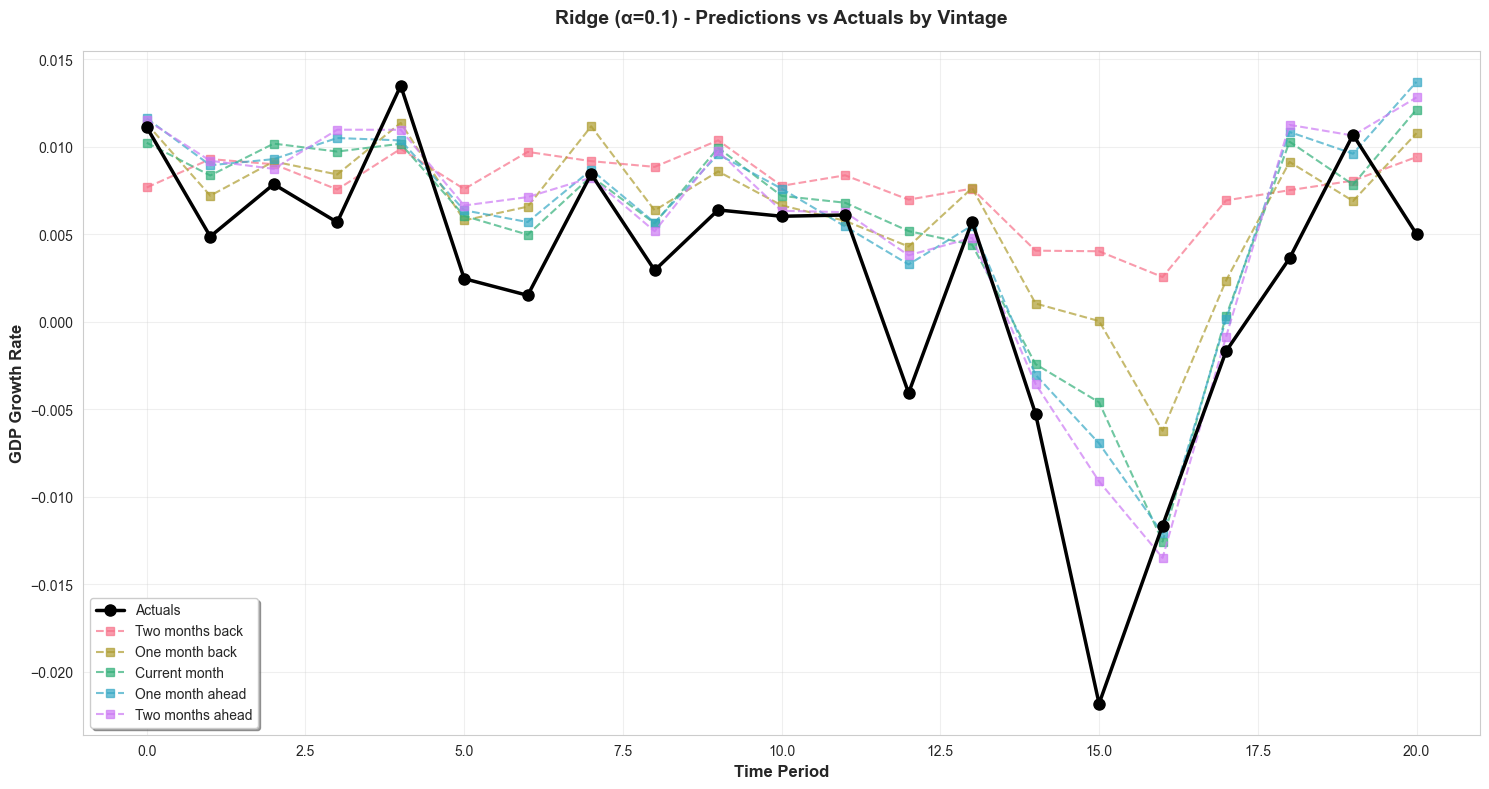

In [19]:
# Create visualization manager
viz = VisualizationManager(evaluator)

# Plot predictions vs actuals
fig1 = viz.plot_predictions_vs_actuals('Ridge (α=0.1)')
plt.show()

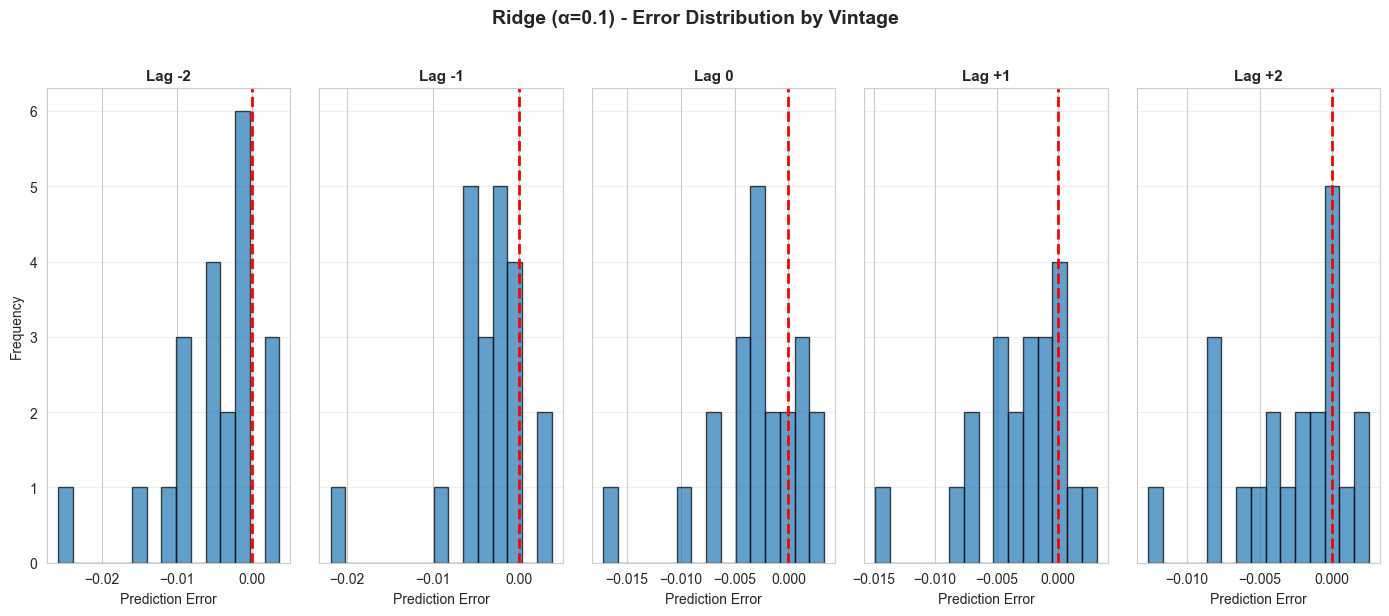

In [20]:
# Plot error distribution
fig2 = viz.plot_error_distribution('Ridge (α=0.1)')
plt.show()

## 5. Compare Multiple Models

In [21]:
# Train Lasso model
lasso_params = {'alpha': 1e-5}
lasso_model = ModelManager(Lasso, lasso_params, config)
lasso_model.run_backtest(data_manager)

evaluator.add_model_results(
    'Lasso (α=1e-5)',
    lasso_model.get_predictions(),
    data_manager.actuals,
    config.lags
)

# Train ElasticNet model
elasticnet_params = {'alpha': 1e-5, 'l1_ratio': 0.25}
elasticnet_model = ModelManager(ElasticNet, elasticnet_params, config)
elasticnet_model.run_backtest(data_manager)

evaluator.add_model_results(
    'ElasticNet',
    elasticnet_model.get_predictions(),
    data_manager.actuals,
    config.lags
)


Running backtest with 1 ensemble model(s)...
  Processing 5/21 dates...
  Processing 5/21 dates...
  Processing 10/21 dates...
  Processing 10/21 dates...
  Processing 15/21 dates...
  Processing 15/21 dates...
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed

Running backtest with 1 ensemble model(s)...
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed

Running backtest with 1 ensemble model(s)...
  Processing 5/21 dates...
  Processing 5/21 dates...
  Processing 10/21 dates...
  Processing 10/21 dates...
  Processing 15/21 dates...
  Processing 15/21 dates...
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed


In [22]:
# Compare all models
print("\nMODEL COMPARISON:")
print("=" * 80)
display(evaluator.get_performance_table().round(6))

print("\n" + evaluator.summary_report())


MODEL COMPARISON:


Model,Vintage,ElasticNet,Lasso (α=1e-5),Ridge (α=0.1),Best Model
0,-2,0.008215,0.009191,0.008167,Ridge (α=0.1)
1,-1,0.007190,0.008148,0.006155,Ridge (α=0.1)
2,0,0.006949,0.007893,0.005311,Ridge (α=0.1)
3,1,0.007643,0.008666,0.004966,Ridge (α=0.1)
4,2,0.004334,0.004458,0.004729,ElasticNet



MODEL EVALUATION SUMMARY

Model: Ridge (α=0.1)
  Average RMSE across vintages: 0.005866
  Best vintage: lag=2 (RMSE=0.004729)

Model: Lasso (α=1e-5)
  Average RMSE across vintages: 0.007671
  Best vintage: lag=2 (RMSE=0.004458)

Model: ElasticNet
  Average RMSE across vintages: 0.006866
  Best vintage: lag=2 (RMSE=0.004334)



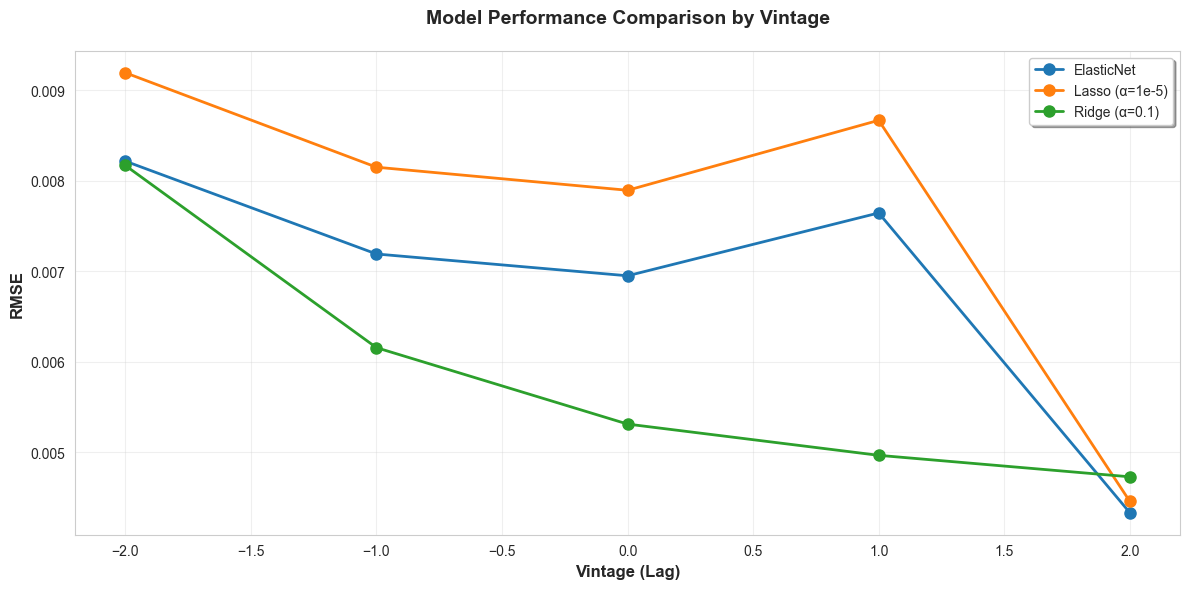

In [23]:
# Visualize comparison
fig_comparison = viz.plot_performance_comparison()
if fig_comparison:
    plt.show()

## 6. Train Ensemble Model (Random Forest)

In [24]:
# Create new config with ensemble
rf_config = NowcastConfig(n_ensemble_models=5, n_lags=4)

# Create new data manager (or reuse existing)
rf_data = DataManager(rf_config).load_data().prepare_test_data()

# Configure Random Forest
rf_params = {
    'n_estimators': 100,
    'criterion': 'squared_error',
    'max_depth': None,
    'min_samples_split': 0.01,
    'min_samples_leaf': 0.01,
    'max_features': 'sqrt',
    'bootstrap': False,
    'random_state': 42
}

# Train with 5-model ensemble
rf_model = ModelManager(RandomForestRegressor, rf_params, rf_config)
rf_model.run_backtest(rf_data)

# Add to evaluator
evaluator.add_model_results(
    'Random Forest (5-ensemble)',
    rf_model.get_predictions(),
    rf_data.actuals,
    rf_config.lags
)

# Updated comparison
print("\nUPDATED MODEL COMPARISON:")
print("=" * 80)
display(evaluator.get_performance_table().round(6))

✓ Loaded data: (913, 25)
✓ Loaded metadata: (24, 8)
✓ Test data prepared: 21 periods

Running backtest with 5 ensemble model(s)...
  Processing 5/21 dates...
  Processing 5/21 dates...
  Processing 10/21 dates...
  Processing 10/21 dates...
  Processing 15/21 dates...
  Processing 15/21 dates...
  Processing 20/21 dates...
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed

UPDATED MODEL COMPARISON:
✓ Backtest complete: 21 periods processed

UPDATED MODEL COMPARISON:


Model,Vintage,ElasticNet,Lasso (α=1e-5),Random Forest (5-ensemble),Ridge (α=0.1),Best Model
0,-2,0.008215,0.009191,0.008604,0.008167,Ridge (α=0.1)
1,-1,0.007190,0.008148,0.008408,0.006155,Ridge (α=0.1)
2,0,0.006949,0.007893,0.006809,0.005311,Ridge (α=0.1)
3,1,0.007643,0.008666,0.004954,0.004966,Random Forest (5-ensemble)
4,2,0.004334,0.004458,0.004378,0.004729,ElasticNet


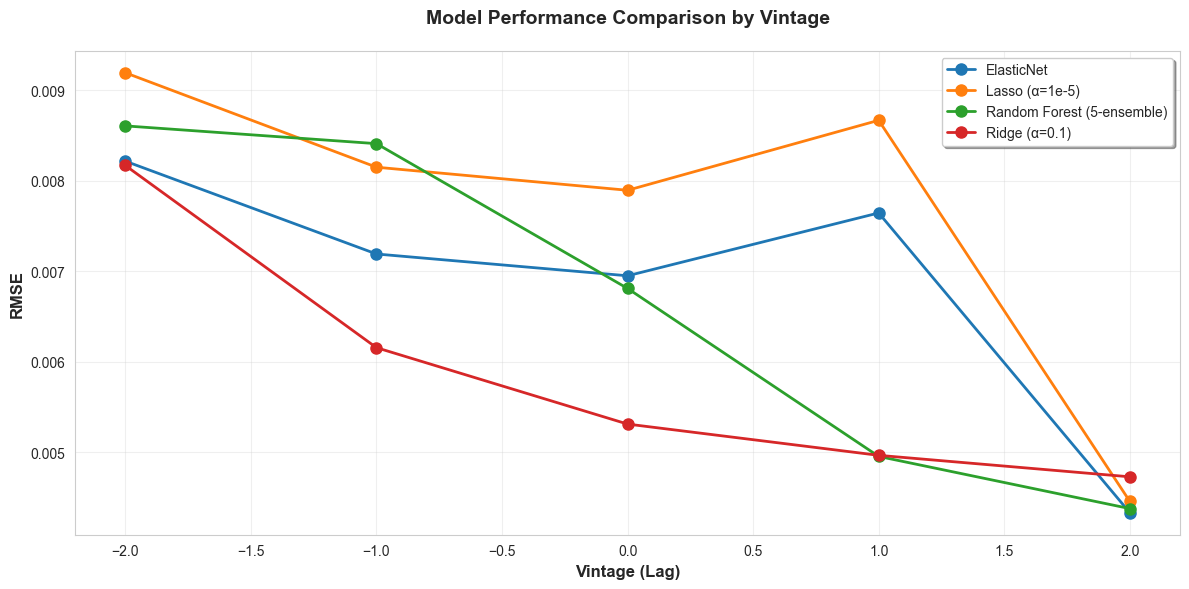

In [25]:
# Updated comparison plot
fig_comparison = viz.plot_performance_comparison()
if fig_comparison:
    plt.show()

## 7. Production Inference

In [26]:
# Create inference pipeline with best model (e.g., Ridge)
inference = InferencePipeline(ridge_model, data_manager, config)

# Predict future quarters
future_dates = ["2010-06-01", "2010-09-01", "2010-12-01", "2011-03-01"]
predictions_df = inference.batch_predict(future_dates)

print("\nFUTURE PREDICTIONS:")
print("=" * 80)
display(predictions_df)


FUTURE PREDICTIONS:


,target_date,prediction,target_variable,n_models,model_class
0,2010-06-01,0.007808,gdpc1,1,Ridge
1,2010-09-01,0.008235,gdpc1,1,Ridge
2,2010-12-01,0.008235,gdpc1,1,Ridge
3,2011-03-01,0.008235,gdpc1,1,Ridge


In [27]:
# Single prediction with details
single_pred = inference.predict_new_date("2011-06-01")

print("\nSINGLE PREDICTION DETAILS:")
print("=" * 60)
for key, value in single_pred.items():
    print(f"{key:20s}: {value}")


SINGLE PREDICTION DETAILS:
target_date         : 2011-06-01
prediction          : 0.008235431128051064
target_variable     : gdpc1
n_models            : 1
model_class         : Ridge


## 8. Custom Configuration Example

In [28]:
# Create custom configuration
custom_config = NowcastConfig(
    target_variable="gdpc1",
    test_start_date="2007-01-01",  # Different test period
    test_end_date="2012-01-01",
    n_lags=6,  # More lags
    lags=list(range(-3, 4)),  # Wider vintage range
    n_ensemble_models=1,
    quarterly_only=True
)

# Load data with custom config
custom_data = DataManager(custom_config)
custom_data.load_data().prepare_test_data()

# Train model
custom_model = ModelManager(Ridge, {'alpha': 0.5}, custom_config)
custom_model.run_backtest(custom_data)

# Evaluate
custom_eval = EvaluationManager()
custom_eval.add_model_results(
    'Custom Ridge',
    custom_model.get_predictions(),
    custom_data.actuals,
    custom_config.lags
)

# Display
print("\nCUSTOM CONFIGURATION RESULTS:")
print("=" * 80)
display(custom_eval.get_performance_table().round(6))

✓ Loaded data: (913, 25)
✓ Loaded metadata: (24, 8)
✓ Test data prepared: 21 periods

Running backtest with 1 ensemble model(s)...
  Processing 5/21 dates...
  Processing 5/21 dates...
  Processing 10/21 dates...
  Processing 10/21 dates...
  Processing 15/21 dates...
  Processing 15/21 dates...
  Processing 20/21 dates...
  Processing 20/21 dates...
✓ Backtest complete: 21 periods processed

CUSTOM CONFIGURATION RESULTS:
✓ Backtest complete: 21 periods processed

CUSTOM CONFIGURATION RESULTS:


Model,Vintage,Custom Ridge
0,-3,NaN
1,-2,NaN
2,-1,NaN
3,0,NaN
4,1,NaN
5,2,NaN
6,3,NaN


## 9. Summary

### Framework Usage Pattern

```python
# 1. Configure
config = NowcastConfig(target_variable="gdpc1", n_lags=4)

# 2. Load Data
data_manager = DataManager(config).load_data().prepare_test_data()

# 3. Train Model
model_manager = ModelManager(Ridge, {'alpha': 0.1}, config)
model_manager.run_backtest(data_manager)

# 4. Evaluate
evaluator = EvaluationManager()
evaluator.add_model_results('Ridge', model_manager.get_predictions(), 
                            data_manager.actuals, config.lags)

# 5. Visualize
viz = VisualizationManager(evaluator)
viz.plot_predictions_vs_actuals('Ridge')

# 6. Inference
inference = InferencePipeline(model_manager, data_manager, config)
predictions = inference.batch_predict(["2010-06-01"])
```

### Refactored original codebase for these purposes

✅ **Clean separation of concerns** - Each class has single responsibility  
✅ **Reusable across notebooks** - Import and use anywhere  
✅ **Easy to extend** - Add new models by creating ModelManager instances  
✅ **Type hints and docstrings** - Clear, maintainable code  
✅ **Method chaining** - Fluent API for convenience  
✅ **Configuration-driven** - Reproducible experiments  
✅ **Production-ready** - InferencePipeline for deployment  

### Next Steps

- Add logging for experiment tracking
- Add model persistence (save/load)
- Add hyperparameter tuning
- Add cross-validation
- Add feature importance analysis
- Add automated reporting